Running Optimization...
Optimization terminated successfully    (Exit mode 0)
            Current function value: -42.67781497632491
            Iterations: 81
            Function evaluations: 623
            Gradient evaluations: 81

Final Parameters:
a1: 14.039
a2: 20.635
R: 25.000
s: 20.000
u: 38.372
v: -41.745


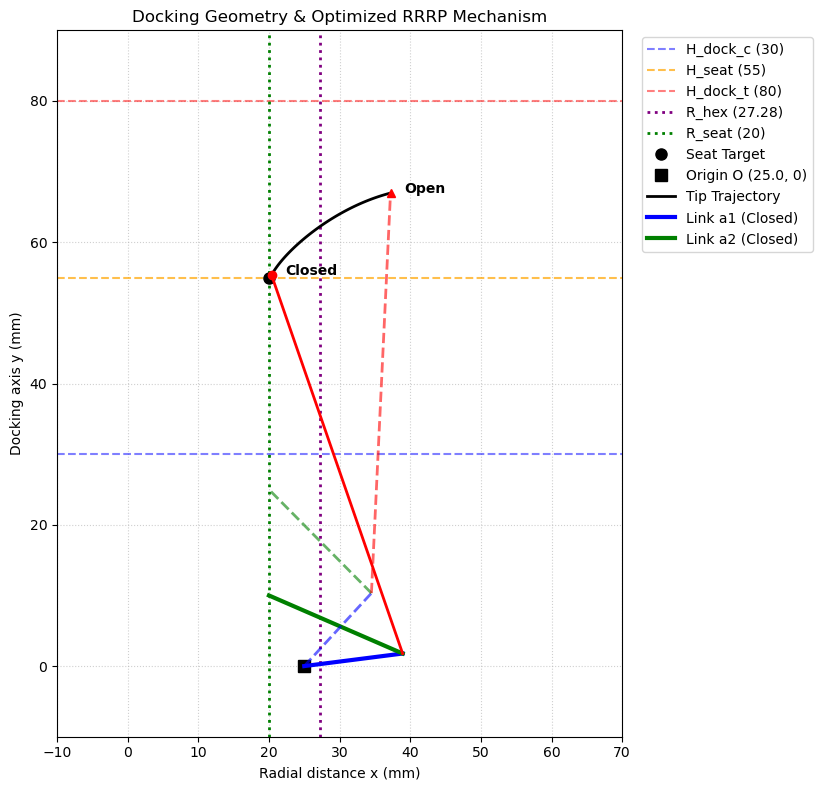

In [ ]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ==========================================
# 1. FIXED SYSTEM PARAMETERS 
# ==========================================
Hboss_t = 30.00
Hboss_c = 20.00
H_dock_c = 30.00
H_dock_t = H_dock_c + Hboss_c + Hboss_t  # 80.00
R_hex = 27.28

# Latch Seat
H_seat = H_dock_c + Hboss_c + 5.00       # 55.00
R_seat = 20.00

# Constraints & Strokes
a3_min = 10.00
a3_max = 25.00  
Rmax = 50.00
X_MAX = 60.00

# ==========================================
# 2. EXACT KINEMATICS
# ==========================================
def rrrp_kinematics(a1, a2, R, s, u, v, a3):
    O = np.array([R, 0.0])
    B = np.array([s, a3])
    d = float(np.linalg.norm(B - O))
    
    # Check if links can physically connect
    if d > (a1 + a2) or d < abs(a1 - a2) or d < 1e-6:
        return None, None, None
        
    # Closed-form circle intersection
    l = (a1**2 - a2**2 + d**2) / (2 * d)
    h_sq = a1**2 - l**2
    h = np.sqrt(max(0.0, h_sq)) 
    
    dir_u = (B - O) / d
    
    # Safe unpacking (No brackets)
    dir_u_x, dir_u_y = dir_u
    dir_v = np.array([-dir_u_y, dir_u_x]) 
    
    A1 = O + l * dir_u + h * dir_v
    A2 = O + l * dir_u - h * dir_v
    
    # Safe unpacking (No brackets)
    A1_x, A1_y = A1
    A2_x, A2_y = A2
    
    # Enforce upward elbow 
    A = A1 if A1_y > A2_y else A2
    
    # Compute Coupler Tip (T)
    AB = B - A
    norm_AB = float(np.linalg.norm(AB))
    t_vec = AB / norm_AB
    
    # Safe unpacking (No brackets)
    t_vec_x, t_vec_y = t_vec
    n_vec = np.array([-t_vec_y, t_vec_x])
    
    tip = A + u * t_vec + v * n_vec
    return tip, A, B

def compute_trajectory_full(params, N=25):
    # Ensure raw floats
    a1, a2, R, s, u, v = map(float, params)
    a3_vals = np.linspace(a3_min, a3_max, N)
    
    traj, A_list, B_list = [], [], []
    for a3 in a3_vals:
        tip, A, B = rrrp_kinematics(a1, a2, R, s, u, v, a3)
        if tip is None:
            return None, None, None, None
        traj.append(tip)
        A_list.append(A)
        B_list.append(B)
        
    return np.array(traj), np.array(A_list), np.array(B_list), a3_vals

# ==========================================
# 3. SMOOTH COST FUNCTION (UI-Bug Proofed)
# ==========================================
def cost_function(params):
    a1, a2, R, s, u, v = map(float, params)
    traj, A_list, B_list, a3_vals = compute_trajectory_full(params)
    
    if traj is None:
        O = np.array([R, 0.0])
        B_mid = np.array([s, (a3_min + a3_max)/2])
        d_mid = float(np.linalg.norm(B_mid - O))
        fail_cost = 1e6 + (d_mid - (a1 + a2))**2 * 1000
        return float(fail_cost) 

    Z = 0  # <--- SAFE INDEXING VARIABLE
    L = -1 # <--- SAFE INDEXING VARIABLE

    x = traj[:, Z]
    y = traj[:, 1]
    penalty = 0.0
    
    # (1) Closed Position (Using Z instead of zero)
    J_closed = (x[Z] - R_seat)**2 + (y[Z] - H_seat)**2
    
    # (2) Capture (Open Position lateral)
    x_open, y_open = x[L], y[L]
    J_capture = -(x_open - R_hex)
    
    # (3) Axial Tolerance
    axial_tol = -1e3
    for i in range(len(x) - 1):
        if (x[i] >= R_hex >= x[i+1]) or (x[i] <= R_hex <= x[i+1]):
            t = (R_hex - x[i]) / (x[i+1] - x[i] + 1e-9)
            y_interp = y[i] + t * (y[i+1] - y[i])
            axial_tol = y_interp - H_seat
            break
    J_axial = -axial_tol
    
    # (4) Monotonicity
    dx = np.diff(x)
    dy = np.diff(y)
    J_mono = np.sum(np.maximum(0, dx)**2) + np.sum(np.maximum(0, dy)**2)
    
    # (5) Smoothness
    J_smooth = np.sum(np.diff(traj, n=2, axis=0)**2)
    
    # (6) Force Transmission
    dx_g, dy_g = np.gradient(x), np.gradient(y)
    vel = np.sqrt(dx_g**2 + dy_g**2) + 1e-6
    alignment = -dy_g / vel 
    J_force = -np.mean(alignment / vel)

    # TRUE SMOOTH PENALTIES
    penalty += np.sum(np.maximum(0, R_seat - x)**2) 
    penalty += np.maximum(0, R_hex - x_open)**2     
    penalty += np.maximum(0, H_seat - y_open)**2    
    penalty += np.maximum(0, y_open - H_dock_t)**2   
    penalty += np.maximum(0, a1 - (Rmax - R))**2    
    penalty += np.maximum(0, 5 - abs(R - s))**2     
    
    # Directional rules (Using Z instead of zero)
    penalty += np.sum(np.maximum(0, -(A_list[:,Z] - R))**2)
    penalty += np.sum(np.maximum(0, -A_list[:,1])**2)
    penalty += np.sum(np.maximum(0, B_list[:,Z] - A_list[:,Z])**2)
    penalty += np.sum(np.maximum(0, -(B_list[:,1] - A_list[:,1]))**2)

    J_raw = (
        20 * J_closed +
        22 * J_capture +
        15 * J_axial +
        15 * J_mono +
        2 * J_smooth +
        8 * J_force +
        50 * penalty 
    )
    
    return float(np.sum(J_raw)) 

# ==========================================
# 4. PLOTTING FUNCTION (UI-Bug Proofed)
# ==========================================
def plot_docking_system(params):
    result = compute_trajectory_full(params, N=50)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot Fixed Geometry
    ax.axhline(H_dock_c, color='blue', linestyle='--', alpha=0.5, label='H_dock_c (30)')
    ax.axhline(H_seat, color='orange', linestyle='--', alpha=0.7, label='H_seat (55)')
    ax.axhline(H_dock_t, color='red', linestyle='--', alpha=0.5, label='H_dock_t (80)')
    ax.axvline(R_hex, color='purple', linestyle=':', linewidth=2, label='R_hex (27.28)')
    ax.axvline(R_seat, color='green', linestyle=':', linewidth=2, label='R_seat (20)')
    ax.plot(R_seat, H_seat, 'ko', markersize=8, label='Seat Target')
    
    R_val = params[2]
    ax.plot(R_val, 0, 'ks', markersize=8, label=f'Origin O ({R_val:.1f}, 0)')
    
    Z = 0  # <--- SAFE INDEXING VARIABLE
    L = -1 # <--- SAFE INDEXING VARIABLE
    
    # Plot Mechanism (Using Z instead of zero)
    if result[Z] is not None:
        traj, A_list, B_list, _ = result
        O_x, O_y = R_val, 0.0
        
        # Trajectory
        traj_x = traj[:, Z]
        traj_y = traj[:, 1]
        ax.plot(traj_x, traj_y, 'k-', linewidth=2, label='Tip Trajectory')
        
        # Closed Position Unpacking
        A_c_x, A_c_y = A_list[Z]
        B_c_x, B_c_y = B_list[Z]
        tip_c_x, tip_c_y = traj[Z]
        
        ax.plot([O_x, A_c_x], [O_y, A_c_y], 'b-', linewidth=3, label='Link a1 (Closed)')
        ax.plot([A_c_x, B_c_x], [A_c_y, B_c_y], 'g-', linewidth=3, label='Link a2 (Closed)')
        ax.plot([A_c_x, tip_c_x], [A_c_y, tip_c_y], 'r-', linewidth=2)
        ax.plot(tip_c_x, tip_c_y, 'ro', markersize=6)
        ax.text(tip_c_x+2, tip_c_y, 'Closed', fontweight='bold')
        
        # Open Position Unpacking
        A_o_x, A_o_y = A_list[L]
        B_o_x, B_o_y = B_list[L]
        tip_o_x, tip_o_y = traj[L]
        
        ax.plot([O_x, A_o_x], [O_y, A_o_y], 'b--', linewidth=2, alpha=0.6)
        ax.plot([A_o_x, B_o_x], [A_o_y, B_o_y], 'g--', linewidth=2, alpha=0.6)
        ax.plot([A_o_x, tip_o_x], [A_o_y, tip_o_y], 'r--', linewidth=2, alpha=0.6)
        ax.plot(tip_o_x, tip_o_y, 'r^', markersize=6)
        ax.text(tip_o_x+2, tip_o_y, 'Open', fontweight='bold')
    else:
        ax.text(10, 40, "Kinematics Invalid: Links separated!", color='red', fontsize=16, fontweight='bold')
    
    ax.set_aspect('equal')
    ax.set_xlim(-10, 70)
    ax.set_ylim(-10, 90)
    ax.set_xlabel('Radial distance x (mm)')
    ax.set_ylabel('Docking axis y (mm)')
    ax.set_title('Docking Geometry & Optimized RRRP Mechanism')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
    plt.tight_layout()
    plt.show()

# ==========================================
# 5. EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    # Better initial guess (known to physically connect)
    p0 = [20.0, 25.0, 35.0, 20.0, 15.0, -5.0] 
    
    bounds = [
        (10.0, 30.0),   # a1
        (10.0, 40.0),   # a2
        (20.0, Rmax),   # R
        (20.0, 50.0),   # s
        (-80.0, 80.0),  # u
        (-80.0, 80.0)   # v 
    ]
    
    # NEW: Formal geometric constraints to prevent the mechanism from breaking
    def reach_constraint(params):
        a1, a2, R, s, u, v = params
        # The max reach distance required (when slider is at highest point)
        max_dist = np.sqrt((R - s)**2 + a3_max**2)
        # The min reach distance required (when slider is at lowest point)
        min_dist = np.sqrt((R - s)**2 + a3_min**2)
        
        return np.array([
            (a1 + a2) - max_dist - 0.5,    # Links must be long enough (with 0.5 margin)
            min_dist - abs(a1 - a2) - 0.5  # Links must be able to fold tight enough
        ])
        
    cons = {'type': 'ineq', 'fun': reach_constraint}
    
    print("Running Optimization...")
    result = minimize(
        cost_function,
        p0,
        method='SLSQP',
        bounds=bounds,
        constraints=cons, # Applying the new constraints here
        options={'maxiter': 500, 'disp': True}
    )
    
    
    print("\nFinal Parameters:")
    labels = ['a1', 'a2', 'R', 's', 'u', 'v']
    for name, val in zip(labels, result.x):
        print(f"{name}: {val:.3f}")
        
    plot_docking_system(result.x)

In [17]:
# ==========================================
# 6. COMPREHENSIVE PERFORMANCE METRICS
# Run this in a new cell after optimization
# ==========================================
def print_comprehensive_metrics(params):
    # Safe indexing variables to bypass UI formatting quirks
    idx_0 = 0
    idx_1 = 1
    last = -1
    
    a1, a2, R, s, u, v = params
    traj, A_list, B_list, a3_vals = compute_trajectory_full(params, N=50)
    
    if traj is None:
        print("Trajectory is invalid. Cannot compute metrics.")
        return
        
    # 1. FIXED GEOMETRY
    print("=== FIXED SYSTEM GEOMETRY ===")
    print(f"R_seat (Target X)    : {R_seat:.2f} mm")
    print(f"H_seat (Target Y)    : {H_seat:.2f} mm")
    print(f"R_hex (Entry X limit): {R_hex:.2f} mm")
    print(f"H_dock_top (Max Y)   : {H_dock_t:.2f} mm")
    print(f"Slider Stroke (a3)   : {a3_min:.2f} to {a3_max:.2f} mm\n")
    
    # 2. OPTIMIZED PARAMETERS
    print("=== OPTIMIZED MECHANISM PARAMETERS ===")
    print(f"Link 1 (a1)          : {a1:.3f} mm")
    print(f"Link 2 (a2)          : {a2:.3f} mm")
    print(f"Origin (R)           : {R:.3f} mm")
    print(f"Slider Pos (s)       : {s:.3f} mm")
    print(f"Coupler offset (u,v) : ({u:.3f}, {v:.3f}) mm\n")
    
    # 3. COORDINATES AT CLOSED POSITION (a3 = min)
    A_c = A_list[idx_0]
    B_c = B_list[idx_0]
    T_c = traj[idx_0]
    print("=== CLOSED POSITION COORDINATES (LATCHED) ===")
    print(f"Origin (O)           : ({R:.2f}, 0.00)")
    print(f"Slider (B)           : ({B_c[idx_0]:.2f}, {B_c[idx_1]:.2f})")
    print(f"Elbow (A)            : ({A_c[idx_0]:.2f}, {A_c[idx_1]:.2f})")
    print(f"Tip (T)              : ({T_c[idx_0]:.2f}, {T_c[idx_1]:.2f})\n")
    
    # 4. COORDINATES AT OPEN POSITION (a3 = max)
    A_o = A_list[last]
    B_o = B_list[last]
    T_o = traj[last]
    print("=== OPEN POSITION COORDINATES (RELEASED) ===")
    print(f"Origin (O)           : ({R:.2f}, 0.00)")
    print(f"Slider (B)           : ({B_o[idx_0]:.2f}, {B_o[idx_1]:.2f})")
    print(f"Elbow (A)            : ({A_o[idx_0]:.2f}, {A_o[idx_1]:.2f})")
    print(f"Tip (T)              : ({T_o[idx_0]:.2f}, {T_o[idx_1]:.2f})\n")
    
    # 5. PERFORMANCE METRICS
    print("=== KEY PERFORMANCE METRICS ===")
    
    # Closed Position Accuracy
    err_x = abs(T_c[idx_0] - R_seat)
    err_y = abs(T_c[idx_1] - H_seat)
    total_err = np.sqrt(err_x**2 + err_y**2)
    print(f"Seat Target Error    : {total_err:.3f} mm (dx: {err_x:.3f}, dy: {err_y:.3f})")
    
    # Capture Margin
    capture_margin = T_o[idx_0] - R_hex
    print(f"Lateral Capture Margin: {capture_margin:.3f} mm (Positive = correctly outside R_hex)")
    
    # Open Height Clearance
    print(f"Open Tip Height      : {T_o[idx_1]:.3f} mm (Constraint: < {H_dock_t})")
    
    # Axial Tolerance
    axial_tol = None
    traj_x = traj[:, idx_0]
    traj_y = traj[:, idx_1]
    for i in range(len(traj_x) - 1):
        # Find exactly where the tip crosses the R_hex boundary line
        if (traj_x[i] >= R_hex >= traj_x[i+1]) or (traj_x[i] <= R_hex <= traj_x[i+1]):
            t = (R_hex - traj_x[i]) / (traj_x[i+1] - traj_x[i] + 1e-9)
            y_interp = traj_y[i] + t * (traj_y[i+1] - traj_y[i])
            axial_tol = y_interp - H_seat
            break
            
    if axial_tol is not None:
        print(f"Axial Tolerance      : {axial_tol:.3f} mm (Height margin above seat when passing R_hex)")
    else:
        print("Axial Tolerance      : N/A (Trajectory never crossed R_hex boundary!)")
        
    # Reach Safety Margin
    max_reach_req = np.sqrt((R - s)**2 + a3_max**2)
    print(f"Max Reach Required   : {max_reach_req:.3f} mm")
    print(f"Link Reach Available : {a1 + a2:.3f} mm")
    print(f"Reach Safety Margin  : {(a1 + a2) - max_reach_req:.3f} mm (Positive = no link separation)")

# Execute the printout using the final output from your optimizer
print_comprehensive_metrics(result.x)

=== FIXED SYSTEM GEOMETRY ===
R_seat (Target X)    : 20.00 mm
H_seat (Target Y)    : 55.00 mm
R_hex (Entry X limit): 27.28 mm
H_dock_top (Max Y)   : 80.00 mm
Slider Stroke (a3)   : 10.00 to 25.00 mm

=== OPTIMIZED MECHANISM PARAMETERS ===
Link 1 (a1)          : 14.039 mm
Link 2 (a2)          : 20.635 mm
Origin (R)           : 25.000 mm
Slider Pos (s)       : 20.000 mm
Coupler offset (u,v) : (38.372, -41.745) mm

=== CLOSED POSITION COORDINATES (LATCHED) ===
Origin (O)           : (25.00, 0.00)
Slider (B)           : (20.00, 10.00)
Elbow (A)            : (38.93, 1.78)
Tip (T)              : (20.37, 55.36)

=== OPEN POSITION COORDINATES (RELEASED) ===
Origin (O)           : (25.00, 0.00)
Slider (B)           : (20.00, 25.00)
Elbow (A)            : (34.51, 10.33)
Tip (T)              : (37.21, 66.96)

=== KEY PERFORMANCE METRICS ===
Seat Target Error    : 0.510 mm (dx: 0.366, dy: 0.355)
Lateral Capture Margin: 9.931 mm (Positive = correctly outside R_hex)
Open Tip Height      : 66.964 mm 

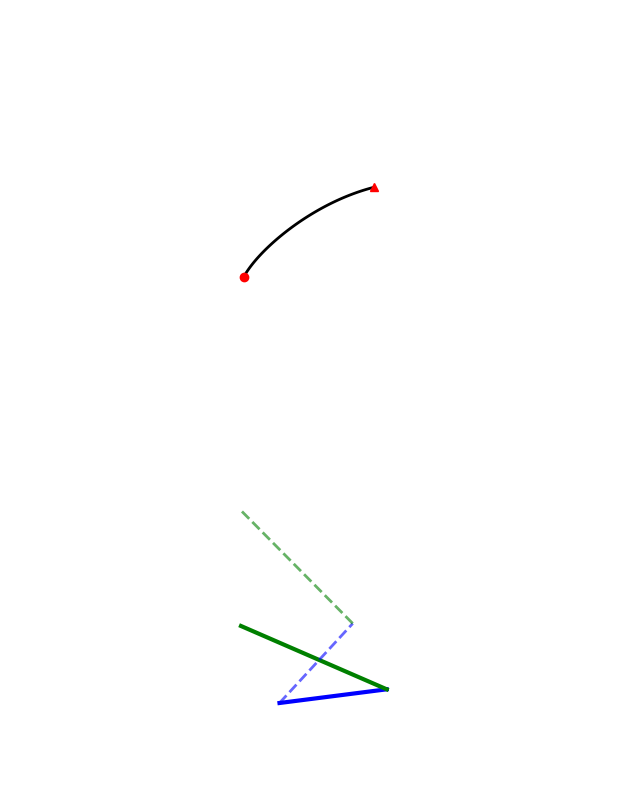

In [18]:
def plot_docking_system2(params):
    result = compute_trajectory_full(params, N=50)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    R_val = params[2]
    
    Z = 0  # <--- SAFE INDEXING VARIABLE
    L = -1 # <--- SAFE INDEXING VARIABLE
    
    # Plot Mechanism (Using Z instead of zero)
    if result[Z] is not None:
        traj, A_list, B_list, _ = result
        O_x, O_y = R_val, 0.0
        
        # Trajectory (Path of the coupler point)
        traj_x = traj[:, Z]
        traj_y = traj[:, 1]
        ax.plot(traj_x, traj_y, 'k-', linewidth=2)
        
        # Closed Position Unpacking
        A_c_x, A_c_y = A_list[Z]
        B_c_x, B_c_y = B_list[Z]
        tip_c_x, tip_c_y = traj[Z]
        
        # Link 1 and Link 2 at Closed Position
        ax.plot([O_x, A_c_x], [O_y, A_c_y], 'b-', linewidth=3)
        ax.plot([A_c_x, B_c_x], [A_c_y, B_c_y], 'g-', linewidth=3)
        
        # Mark the tip point (optional, keeps the trajectory anchored)
        ax.plot(tip_c_x, tip_c_y, 'ro', markersize=6)
        
        # Open Position Unpacking
        A_o_x, A_o_y = A_list[L]
        B_o_x, B_o_y = B_list[L]
        tip_o_x, tip_o_y = traj[L]
        
        # Link 1 and Link 2 at Open Position
        ax.plot([O_x, A_o_x], [O_y, A_o_y], 'b--', linewidth=2, alpha=0.6)
        ax.plot([A_o_x, B_o_x], [A_o_y, B_o_y], 'g--', linewidth=2, alpha=0.6)
        
        # Mark the tip point
        ax.plot(tip_o_x, tip_o_y, 'r^', markersize=6)
        
    else:
        ax.text(10, 40, "Kinematics Invalid: Links separated!", color='red', fontsize=16, fontweight='bold')
    
    # Formatting (Minimalist)
    ax.set_aspect('equal')
    ax.set_xlim(-10, 70)
    ax.set_ylim(-10, 90)
    
    # Turn off axes, ticks, borders, and grids entirely
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()


plot_docking_system2(result.x)